In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy.stats import norm
import pytensor.tensor as pt
import arviz as az
from matplotlib.ticker import MultipleLocator

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data = pd.read_csv(file_path, header=None)
spectrum_50 = data[0].values
t_50 = 4279386 # 50 days exposure
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev>=0) & (E_kev <= 3000)
E_kev = E_kev[mask]
spectrum_50 = spectrum_50[mask]
spectrum_50_norm = spectrum_50/t_50

In [3]:
file_path = "csv-files/bkg.csv"
data = pd.read_csv(file_path, header=None)
spectrum_bkg = data[0].values
t_bkg = 4143234 # 40 days exposure
spectrum_bkg = spectrum_bkg[mask]
spectrum_bkg_norm = spectrum_bkg  / t_bkg

In [4]:
def sigma_fun(E):
    A = 3.68436e1
    B = 1.72714e4
    return (E * np.sqrt(A/E + B/E**2)) / 2.355/100

In [5]:
mu_signal = 778
sigma_signal = sigma_fun(mu_signal)

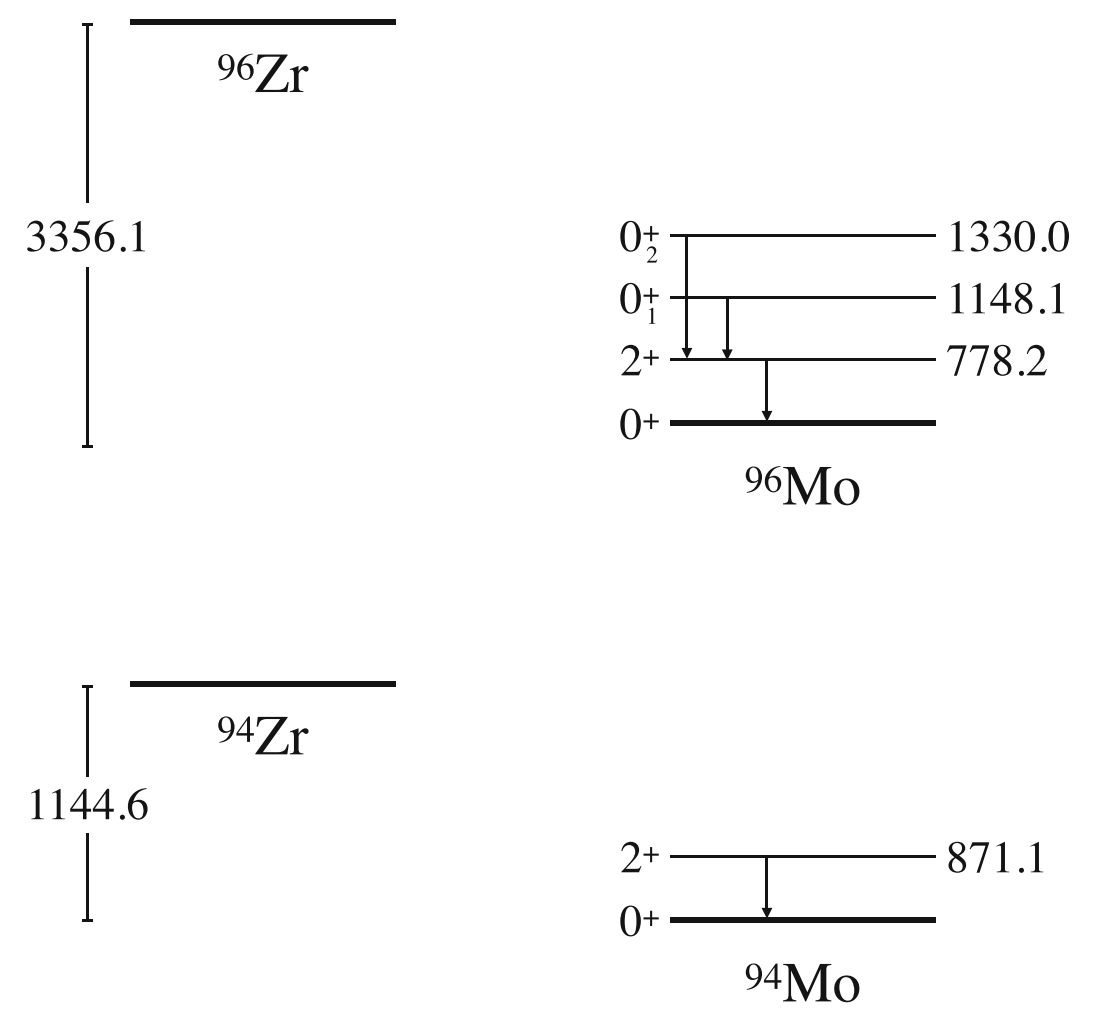


In [6]:
bb_peaks = np.sort([551.8, 369.9, 778.2])

In [23]:
ROIs = [[320,380],
        [500,580],
        [730,800]]

C:\Users\rirri\AppData\Local\Temp\ipykernel_29040\3056724278.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


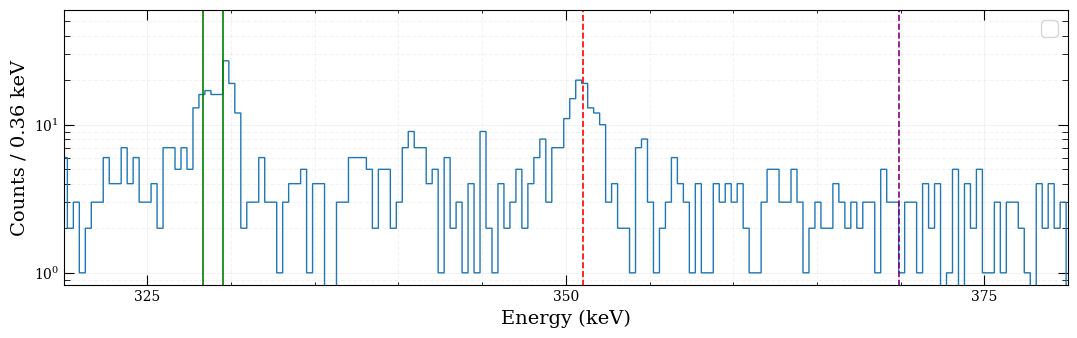

In [31]:

# Stile da paper (EPJ-like)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (11, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

plt.figure()
ax = plt.gca()


dx_major = 25
dx_minor = 5

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

#bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/56))
bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)))
counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spectrum_50,   
                               histtype='step',
                               )
db = bin_edge[1]- bin_edge[0]



plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db:.2f} keV')
#plt.xlim(300, 900)
plt.xlim(ROIs[0])
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

peak = 778
d = 200
plt.vlines([bb_peaks[2]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([bb_peaks[0]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([bb_peaks[1]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([328.3], ymin=1e-3, ymax=1e3, colors="green")  # AC-228
plt.vlines([329.5], ymin=1e-3, ymax=1e3, colors="green")  # AC-228
plt.vlines([351], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #Bi-211
plt.vlines([511], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #ann
plt.vlines([583], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #Tl-208
#plt.xlim(bb_peaks[0] - d, bb_peaks[0] + d)
plt.savefig("spectrum_50_days.png")
plt.show()

--------

# Energy resolution

In [25]:
def sigma_fun(E):
    A = 3.68436e1
    B = 1.72714e4
    return (E * np.sqrt(A/E + B/E**2)) / 2.355/100

----------

# Picco 0

In [46]:
def fit_double_gaussian_poisson_plot(E, N, center1, center2, de):
    """
    Fit di due gaussiane + fondo lineare con likelihood di Poisson.
    Le due gaussiane condividono la stessa sigma.

    Produce:
      1) Istogramma + fit
      2) Profile likelihood ΔNLL per tutti i parametri con ±1σ interpolati

    Restituisce:
      fit_values, err_minus_all, err_plus_all, result
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # ==========================
    # Bin
    # ==========================
    bins = np.linspace(min(E), max(E), int(len(E)) + 1)
    db = bins[1] - bins[0]

    counts, edges = np.histogram(E, bins=bins, weights=N)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    # ==========================
    # ROI
    # ==========================
    roi = (min(center1, center2) - de,
           max(center1, center2) + de)

    mask = (E >= roi[0]) & (E <= roi[1])

    counts_roi = N[mask]
    centers_roi = E[mask]

    # ==========================
    # Modello:
    # doppia gaussiana con sigma comune
    # ==========================
    def model(params, x):

        A1, A2, mu1, mu2, sigma,  B = params

        G1 = (
            A1
            * (1 / (sigma * np.sqrt(2 * np.pi)))
            * np.exp(-(x - mu1) ** 2 / (2 * sigma ** 2))
        )

        G2 = (
            A2
            * (1 / (sigma * np.sqrt(2 * np.pi)))
            * np.exp(-(x - mu2) ** 2 / (2 * sigma ** 2))
        )

        #background = M * x + B
        background = + B

        return G1 + G2 + background

    # ==========================
    # Negative log-likelihood Poisson
    # ==========================
    def nll(params):

        lam = model(params, centers_roi)
        lam = np.clip(lam, 1e-12, None)

        return np.sum(lam - counts_roi * np.log(lam))

    # ==========================
    # Stime iniziali
    # ==========================
    total_counts = np.sum(counts_roi)

    A10 = total_counts / 2
    A20 = total_counts / 2

    mu10 = center1
    mu20 = center2

    sigma0 = sigma_fun((center1 + center2) / 2)

    #M0 = 0.0
    B0 = max(np.min(counts_roi), 1e-3)

    initial = [
        A10,
        A20,
        mu10,
        mu20,
        sigma0,
       # M0,
        B0,
    ]

    bounds = [
        (A10*0.99, A10*1.01),          # A1
        (A20*0.99, A20*1.01),          # A2
        (roi[0], roi[1]),   # mu1
        (roi[0], roi[1]),   # mu2
        (1e-5, 100),        # sigma comune
        #(-10, None),        # M
        (1e-7, None),       # B
    ]

    # ==========================
    # Minimizzazione
    # ==========================
    result = minimize(
        nll,
        initial,
        bounds=bounds,
        method="L-BFGS-B"
    )

    fit_values = result.x

    param_names = [
        'A1',
        'A2',
        'mu1',
        'mu2',
        'sigma',
        'M',
        'B'
    ]

    print("\nBest fit:")
    for n, v in zip(param_names, fit_values):
        print(f"{n} = {v:.5f}")

    # ==========================
    # Plot fit
    # ==========================
    fig, ax = plt.subplots(figsize=(6, 4))

    plt.hist(
        E,
        bins=bins,
        weights=N,
        color='tab:gray',
        histtype='step',
        label='Data'
    )

    plt.scatter(
        centers_roi,
        counts_roi,
        color='black',
        s=12
    )

    x_plot = np.linspace(roi[0], roi[1], 2000)

    y_plot = model(fit_values, x_plot)

    plt.plot(
        x_plot,
        y_plot,
        color='deepskyblue',
        lw=2,
        label='Total fit'
    )

    # componenti separate
    #A1, A2, mu1, mu2, sigma, M, B = fit_values
    A1, A2, mu1, mu2, sigma, B = fit_values

    G1 = (
        A1
        * (1 / (sigma * np.sqrt(2 * np.pi)))
        * np.exp(-(x_plot - mu1) ** 2 / (2 * sigma ** 2))
    )

    G2 = (
        A2
        * (1 / (sigma * np.sqrt(2 * np.pi)))
        * np.exp(-(x_plot - mu2) ** 2 / (2 * sigma ** 2))
    )

    BG =  B

    plt.plot(x_plot, G1, '--', label='Gaussian 1')
    plt.plot(x_plot, G2, '--', label='Gaussian 2')
    #plt.plot(x_plot, BG, ':', label='Background')

    plt.axvline(mu1, ls='--', alpha=0.6)
    plt.axvline(mu2, ls='--', alpha=0.6)

    plt.xlim(roi)

    plt.xlabel("Energy (keV)", size=13)
    plt.ylabel(f"Counts / {db:.3f} keV", size=13)

    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ==========================
    # PROFILE LIKELIHOOD
    # ==========================
    scans = []
    delta_nlls = []

    err_minus_all = []
    err_plus_all = []

    nll_min = nll(fit_values)

    for i, pname in enumerate(param_names):

        val_fit = fit_values[i]

        # range scans
        if "A" in pname:
            scan = np.linspace(
                max(1e-3, val_fit * 0.2),
                val_fit * 2,
                60
            )

        elif "mu" in pname:
            scan = np.linspace(
                val_fit - 3 * sigma,
                val_fit + 3 * sigma,
                60
            )

        elif pname == "sigma":
            scan = np.linspace(
                val_fit * 0.3,
                val_fit * 2,
                60
            )

        else:
            scan = np.linspace(
                val_fit - abs(val_fit) * 2 - 1,
                val_fit + abs(val_fit) * 2 + 1,
                60
            )

        delta_nll = []

        for x_val in scan:

            def nll_profile(other_params):

                full = fit_values.copy()

                cnt = 0

                for j in range(len(fit_values)):

                    if j == i:
                        full[j] = x_val

                    else:
                        full[j] = other_params[cnt]
                        cnt += 1

                return nll(full)

            other_initial = [
                fit_values[j]
                for j in range(len(fit_values))
                if j != i
            ]

            other_bounds = [
                bounds[j]
                for j in range(len(fit_values))
                if j != i
            ]

            res2 = minimize(
                nll_profile,
                other_initial,
                bounds=other_bounds,
                method="L-BFGS-B"
            )

            delta_nll.append(res2.fun - nll_min)

        delta_nll = np.array(delta_nll)

        scans.append(scan)
        delta_nlls.append(delta_nll)

        # ==========================
        # Errori 1σ
        # ==========================
        scan_left = scan[scan < val_fit]
        delta_left = delta_nll[scan < val_fit]

        if np.any(delta_left >= 0.5):

            err_minus = (
                val_fit
                - np.interp(
                    0.5,
                    delta_left[::-1],
                    scan_left[::-1]
                )
            )

        else:
            err_minus = np.nan

        scan_right = scan[scan > val_fit]
        delta_right = delta_nll[scan > val_fit]

        if np.any(delta_right >= 0.5):

            err_plus = (
                np.interp(
                    0.5,
                    delta_right,
                    scan_right
                )
                - val_fit
            )

        else:
            err_plus = np.nan

        err_minus_all.append(err_minus)
        err_plus_all.append(err_plus)

        print(
            f"{pname} = "
            f"{val_fit:.5f}"
            f" -{err_minus:.5f}"
            f"/+{err_plus:.5f}"
        )

    # ==========================
    # Plot ΔNLL
    # ==========================
    npars = len(param_names)

    ncols = 2
    nrows = int(np.ceil(npars / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(8, 3 * nrows)
    )

    axes = np.array(axes).flatten()

    for i in range(npars):

        ax = axes[i]

        ax.plot(scans[i], delta_nlls[i])

        ax.axhline(0.5, color='red', ls='--')

        ax.axvline(fit_values[i], color='green', ls='--')

        if not np.isnan(err_minus_all[i]):
            ax.axvline(
                fit_values[i] - err_minus_all[i],
                color='orange',
                ls='--'
            )

        if not np.isnan(err_plus_all[i]):
            ax.axvline(
                fit_values[i] + err_plus_all[i],
                color='purple',
                ls='--'
            )

        ax.set_xlabel(param_names[i])
        ax.set_ylabel("ΔNLL")

        ax.grid(alpha=0.3)

    # subplot vuoti
    for j in range(npars, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return (
        fit_values,
        err_minus_all,
        err_plus_all,
        result
    )

In [48]:
spectrum_50[(E_kev >325) & (E_kev < 340)]

array([ 3,  4,  2,  7,  7,  5,  7,  5, 13, 16, 17, 16, 16, 27, 19, 12,  2,
        3,  3,  6,  3,  3,  1,  3,  4,  4,  5,  1,  4,  4,  0,  0,  3,  3,
        6,  6,  6,  5,  2,  5,  5,  2])

In [ ]:


def fit_double_gaussian_poisson_plot(
    E,
    N,
    center1,
    center2,
    de,
    sigma_fixed=None
):

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # =====================================================
    # BINNING
    # =====================================================
    bins = np.linspace(min(E), max(E), len(E) + 1)

    counts, edges = np.histogram(
        E,
        bins=bins,
        weights=N
    )

    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    db = edges[1] - edges[0]

    # =====================================================
    # ROI
    # =====================================================
    roi = (
        min(center1, center2) - de,
        max(center1, center2) + de
    )

    mask_roi = (
        (bin_centers >= roi[0])
        &
        (bin_centers <= roi[1])
    )

    centers_roi = bin_centers[mask_roi]
    counts_roi = counts[mask_roi]

    # =====================================================
    # SIGMA FISSATA
    # =====================================================
    if sigma_fixed is None:
        sigma_fixed = sigma_fun((center1 + center2)/2)

    sigma = sigma_fixed

    # =====================================================
    # MODELLO
    # =====================================================
    # PARAMETRI:
    # A1, A2, mu1, mu2, B
    # =====================================================

    def model(params, x):

        A1, A2, mu1, mu2, B = params

        G1 = (
            A1
            /
            (sigma * np.sqrt(2*np.pi))
            *
            np.exp(-(x-mu1)**2/(2*sigma**2))
        )

        G2 = (
            A2
            /
            (sigma * np.sqrt(2*np.pi))
            *
            np.exp(-(x-mu2)**2/(2*sigma**2))
        )

        background = B

        # conteggi/bin
        return (G1 + G2 + background) * db

    # =====================================================
    # NLL POISSON
    # =====================================================
    def nll(params):

        A1, A2, mu1, mu2, B = params

        # evita scambio gaussiane
        if mu1 >= mu2:
            return 1e30

        lam = model(params, centers_roi)

        lam = np.clip(lam, 1e-12, None)

        return np.sum(
            lam - counts_roi*np.log(lam)
        )

    # =====================================================
    # STIME INIZIALI
    # =====================================================
    total_counts = np.sum(counts_roi)

    A10 = total_counts*0.2 
    A20 = total_counts *0.8

    B0 = np.median(counts_roi[:5])

    initial = [
        A10,
        A20,
        center1,
        center2,
        B0
    ]

    # =====================================================
    # BOUNDS
    # =====================================================
    bounds = [

        (0, total_counts*0.2 ),
        (total_counts*0.2 , total_counts*10),

        (center1*0.999, center1*1.001),
        (center2*0.999, center2*1.001),

        (0, np.max(counts_roi))
    ]

    # =====================================================
    # FIT
    # =====================================================
    result = minimize(
        nll,
        initial,
        bounds=bounds,
        method='L-BFGS-B'
    )

    fit_values = result.x

    param_names = [
        'A1',
        'A2',
        'mu1',
        'mu2',
        'B'
    ]

    print('\n===== BEST FIT =====')

    for n, v in zip(param_names, fit_values):
        print(f'{n:5s} = {v:.5f}')

    print(f'sigma = {sigma:.5f} (fixed)')

    # =====================================================
    # PLOT FIT
    # =====================================================
    fig, ax = plt.subplots(figsize=(7,5))

    plt.hist(
        E,
        bins=bins,
        weights=N,
        histtype='step',
        lw=1.8,
        color='black',
        label='Data'
    )

    plt.errorbar(
        centers_roi,
        counts_roi,
        yerr=np.sqrt(np.clip(counts_roi,1,None)),
        fmt='o',
        ms=4,
        color='black'
    )

    x_plot = np.linspace(roi[0], roi[1], 3000)

    y_plot = model(fit_values, x_plot)

    plt.plot(
        x_plot,
        y_plot,
        color='deepskyblue',
        lw=2.5,
        label='Total fit'
    )

    A1, A2, mu1, mu2, B = fit_values

    G1 = (
        A1
        /
        (sigma*np.sqrt(2*np.pi))
        *
        np.exp(-(x_plot-mu1)**2/(2*sigma**2))
    ) * db

    G2 = (
        A2
        /
        (sigma*np.sqrt(2*np.pi))
        *
        np.exp(-(x_plot-mu2)**2/(2*sigma**2))
    ) * db

    BG = np.ones_like(x_plot) * B * db

    plt.plot(
        x_plot,
        G1,
        '--',
        lw=2,
        label='Gaussian 1'
    )

    plt.plot(
        x_plot,
        G2,
        '--',
        lw=2,
        label='Gaussian 2'
    )

    plt.plot(
        x_plot,
        BG,
        ':',
        lw=2,
        label='Background'
    )

    plt.axvline(mu1, ls='--', alpha=0.6)
    plt.axvline(mu2, ls='--', alpha=0.6)

    plt.xlabel('Energy (keV)', fontsize=13)
    plt.ylabel(f'Counts / {db:.3f} keV', fontsize=13)

    plt.xlim(roi)

    ymax = max(counts_roi) * 1.4
    plt.ylim(0, ymax)

    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # HESSIAN ERRORS
    # =====================================================
    try:

        hess_inv = result.hess_inv.todense()

        errors = np.sqrt(np.diag(hess_inv))

    except:

        errors = np.full(len(fit_values), np.nan)

    print('\n===== ERRORS =====')

    for n, e in zip(param_names, errors):
        print(f'{n:5s} = ± {e:.5f}')

    return fit_values, errors, result




===== BEST FIT =====
A1    = 60.37850
A2    = 50.42648
mu1   = 329.07060
mu2   = 330.06960
B     = 10.54594
sigma = 0.72841 (fixed)


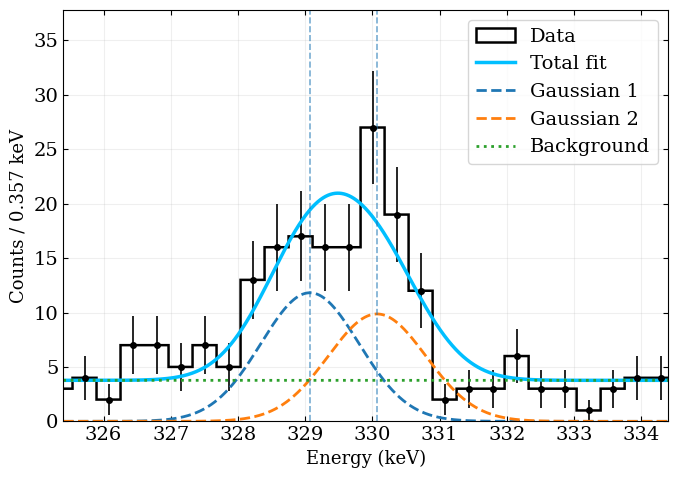


===== ERRORS =====
A1    = ± 91.67209
A2    = ± 94.93717
mu1   = ± 1.00000
mu2   = ± 1.00000
B     = ± 3.60381


In [79]:
fit_val, fit_err, res = fit_double_gaussian_poisson_plot(
    E_kev,
    spectrum_50,
    center1=329.4,
    center2=330.4,
    de=4
)